# 2) Analyze Source Collection and Target Files

This notebook analyzes the source sound collection built in Notebook 1 and two target audio files using Essentia.

**What this notebook does:**
1. Defines an extended `analyze_sound()` function with additional audio features
2. Analyzes the source collection and saves results to CSV
3. Analyzes two target files (dark techno kick loop and acid bass loop)
4. Runs a **frame size experiment** on the target to see how segmentation granularity affects the result
5. Runs a **beat-synchronous segmentation** experiment on the percussive target

**Features extracted:**
- Loudness, RMS Energy
- MFCCs (13 coefficients)
- Spectral Centroid (brightness)
- Zero Crossing Rate (percussive vs tonal)
- Spectral Flatness (noise vs tonal)

## 1. Setup

In [1]:
%pip install essentia soundfile -q
%pip install git+https://github.com/mtg/freesound-python.git -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
%cd /content/audio-mosaicing

In [2]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import essentia
import essentia.standard as estd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Audio

print("Essentia version:", essentia.__version__)
print("Working directory:", os.getcwd())
# ── Color palette ──────────────────────────────────────────────────────────────
C = {
    'deep_purple' : '#3B1055',
    'mid_purple'  : '#6B2F9B',
    'light_purple': '#9D6BBF',
    'accent'      : '#C084FC',
    'dark_grey'   : '#2E2E3A',
    'mid_grey'    : '#6B6B7E',
    'light_grey'  : '#B0B0C4',
}

plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.15,
    'grid.color'       : '#888888',
    'font.size'        : 11,
})


Essentia version: 2.1-beta6-dev
Working directory: /content


## 2. Pre-processing: Trim Leading Silence

The acid bass loop has ~2.7 seconds of silence at the beginning.
We trim it before analysis so the mosaicing only works with actual audio content.

In [3]:
ACID_PATH = '795260__acidkekkonen__acid-kekkonen-hapan-yhteiskunta-best-mongolia-1-acid-bass-loop.wav'
ACID_TRIMMED_PATH = 'acid_bass_trimmed.wav'

if os.path.exists(ACID_PATH):
    audio, sr = sf.read(ACID_PATH)
    threshold = 0.001
    start = np.argmax(np.abs(audio) > threshold)
    audio_trimmed = audio[start:]
    sf.write(ACID_TRIMMED_PATH, audio_trimmed, sr)
    print(f"Trimmed {start/sr:.2f}s of silence from the beginning")
    print(f"Original duration: {len(audio)/sr:.2f}s → Trimmed duration: {len(audio_trimmed)/sr:.2f}s")
else:
    print(f"File not found: {ACID_PATH}")

Trimmed 5.45s of silence from the beginning
Original duration: 18.08s → Trimmed duration: 12.63s


## 3. Extended Analysis Function

The `analyze_sound()` function splits each audio file into frames and extracts the following features per frame:

| Feature | Description | Why useful |
|---|---|---|
| `loudness` | Perceived loudness (normalized) | Match energy levels |
| `rms` | Root Mean Square energy | Alternative energy measure |
| `mfcc_0..12` | Mel-Frequency Cepstral Coefficients | Timbre similarity |
| `spectral_centroid` | Weighted mean frequency (brightness) | Distinguish bright vs dark sounds |
| `zero_crossing_rate` | Rate of sign changes | Distinguish percussive vs tonal |
| `spectral_flatness` | How noise-like vs tonal the sound is | Useful for texture matching |

In [4]:
def analyze_sound(audio_path, frame_size=None, audio_id=None, sync_with_beats=False):
    """
    Analyze an audio file frame by frame and extract audio features.

    Parameters:
        audio_path     : path to the audio file
        frame_size     : number of samples per frame (None = whole file as one frame)
        audio_id       : identifier to tag each frame row
        sync_with_beats: if True, use beat positions as frame boundaries instead of fixed size

    Returns:
        list of dicts, one per frame, each containing metadata + features
    """
    analysis_output = []

    loader = estd.MonoLoader(filename=audio_path)
    audio = loader()

    if frame_size is None:
        frame_size = len(audio)
    if frame_size % 2 != 0:
        frame_size += 1

    # Determine frame boundaries
    if sync_with_beats:
        beat_tracker = estd.BeatTrackerDegara()
        beat_positions = beat_tracker(audio)
        beat_positions = [int(round(p * 44100)) for p in beat_positions]
        frame_start_end_samples = list(zip(beat_positions[:-1], beat_positions[1:]))
    else:
        frame_start_samples = range(0, len(audio), frame_size)
        frame_start_end_samples = list(zip(frame_start_samples, list(frame_start_samples)[1:]))

    # Instantiate algorithms once (more efficient)
    loudness_algo    = estd.Loudness()
    w_algo           = estd.Windowing(type='hann')
    spectrum_algo    = estd.Spectrum()
    mfcc_algo        = estd.MFCC()
    centroid_algo    = estd.Centroid(range=22050)
    zcr_algo         = estd.ZeroCrossingRate()
    flatness_algo    = estd.Flatness()
    key_algo         = estd.KeyExtractor()

    for count, (fstart, fend) in enumerate(frame_start_end_samples):
        frame = audio[fstart:fend]
        if len(frame) == 0:
            continue

        frame_output = {
            'freesound_id' : audio_id,
            'id'           : f'{audio_id}_f{count}',
            'path'         : audio_path,
            'start_sample' : fstart,
            'end_sample'   : fend,
        }

        # Loudness (normalized by frame length)
        frame_output['loudness'] = loudness_algo(frame) / len(frame)

        # RMS energy
        frame_output['rms'] = float(np.sqrt(np.mean(frame ** 2)))

        # Spectrum (needed by several algorithms)
        spec = spectrum_algo(w_algo(frame))

        # MFCCs
        _, mfcc_coeffs = mfcc_algo(spec)
        frame_output.update({f'mfcc_{j}': mfcc_coeffs[j] for j in range(len(mfcc_coeffs))})

        # Spectral Centroid (brightness)
        frame_output['spectral_centroid'] = centroid_algo(spec)

        # Zero Crossing Rate
        frame_output['zero_crossing_rate'] = zcr_algo(frame)

        # Spectral Flatness
        frame_output['spectral_flatness'] = flatness_algo(spec)

        # Tonality (key, scale, key_strength)
        # Note: key detection is more reliable on longer frames (>= 4096 samples)
        try:
            key, scale, key_strength = key_algo(frame)
            frame_output['key']          = key
            frame_output['scale']        = scale
            frame_output['key_strength'] = float(key_strength)
        except Exception:
            frame_output['key']          = 'unknown'
            frame_output['scale']        = 'unknown'
            frame_output['key_strength'] = 0.0

        analysis_output.append(frame_output)

    return analysis_output

## 4. Analyze Source Collection

Analyze all 63 sounds in the source collection using a frame size of **8192 samples (~185ms)**.
Results are saved to `dataframe_source.csv`.

In [5]:
DATAFRAME_FILENAME        = 'dataframe.csv'
DATAFRAME_SOURCE_FILENAME = 'dataframe_source.csv'

df = pd.read_csv(DATAFRAME_FILENAME, index_col=0)
print(f"Source collection: {len(df)} sounds")

analyses = []
for i in range(len(df)):
    sound = df.iloc[i]
    print(f'Analyzing [{i+1}/{len(df)}] id={sound["freesound_id"]}', end='\r')
    try:
        result = analyze_sound(sound['path'], frame_size=8192, audio_id=sound['freesound_id'])
        analyses += result
    except RuntimeError:
        continue

df_source = pd.DataFrame(analyses)
df_source.to_csv(DATAFRAME_SOURCE_FILENAME)
print(f'\nSaved {len(df_source)} frames → {DATAFRAME_SOURCE_FILENAME}')
display(df_source.head())
df_source.describe()

Source collection: 63 sounds

Saved 398 frames → dataframe_source.csv


,freesound_id,id,path,start_sample,end_sample,loudness,rms,mfcc_0,mfcc_1,mfcc_2,...,mfcc_9,mfcc_10,mfcc_11,mfcc_12,spectral_centroid,zero_crossing_rate,spectral_flatness,key,scale,key_strength
0,132584,132584_f0,files/132584_2409787-hq.ogg,0,8192,0.016301,0.426159,-1144.316284,162.570221,140.591125,...,13.055492,14.188225,14.120167,12.311432,58.461002,0.002441,0.0,C#,minor,0.668994
1,132584,132584_f1,files/132584_2409787-hq.ogg,8192,16384,0.001751,0.080617,-1229.118896,50.385822,49.694302,...,34.829105,31.907753,28.970448,26.074848,56.805447,0.001831,0.0,E,minor,0.687967
2,132584,132584_f2,files/132584_2409787-hq.ogg,16384,24576,0.000037,0.004527,-1249.117798,22.292068,22.161190,...,19.018871,18.304573,17.541729,16.737419,591.765198,0.003418,0.0,F,major,0.478491
3,673512,673512_f0,files/673512_3130497-hq.ogg,0,8192,0.013325,0.366649,-1120.314697,186.085968,139.704285,...,16.258755,14.979012,13.366108,11.740959,95.194511,0.007690,0.0,C,major,0.642107
4,673512,673512_f1,files/673512_3130497-hq.ogg,8192,16384,0.003466,0.134203,-1230.337769,48.668720,47.998318,...,34.143925,31.567818,29.036732,26.605610,39.595295,0.001465,0.0,C,minor,0.550222


,freesound_id,start_sample,end_sample,loudness,rms,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,spectral_centroid,zero_crossing_rate,spectral_flatness,key_strength
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,...,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,419159.371859,36246.512563,44438.512563,0.004722,0.144573,-913.455261,123.766449,11.244101,26.430286,8.134033,...,7.335505,1.782684,5.290597,2.952348,1.359130,0.606468,2426.997671,0.066046,0.058234,0.578981
std,207232.762729,30836.506320,30836.506320,0.005857,0.149112,242.698685,96.572533,61.493423,33.808529,28.883043,...,15.422311,14.896009,12.758981,10.923120,11.518445,11.354778,2376.228523,0.095532,0.147593,0.199750
min,5567.000000,0.000000,8192.000000,0.000000,0.000000,-1264.911621,-245.757843,-125.922546,-59.867115,-69.059013,...,-42.538059,-94.744263,-33.517574,-35.664150,-46.893871,-44.473663,0.000000,0.000000,0.000000,0.000000
25%,337873.000000,8192.000000,16384.000000,0.000227,0.017577,-1135.455750,50.278777,-34.902966,0.000031,-14.199112,...,-1.455057,-5.950049,-1.195074,-2.478104,-2.578328,-4.057411,771.039093,0.006989,0.000000,0.493092
50%,431944.000000,32768.000000,40960.000000,0.001921,0.086398,-908.817047,134.063530,6.538850,24.231235,5.701778,...,4.841992,1.097935,3.768934,2.726624,1.733977,-0.000042,1671.571838,0.026794,0.000000,0.606262
75%,578558.250000,57344.000000,65536.000000,0.007999,0.250524,-710.126373,208.111618,44.718342,51.660691,28.474529,...,16.126388,10.468751,12.389872,9.698348,7.103141,5.507969,3443.334656,0.083618,0.007345,0.706482
max,827848.000000,122880.000000,131072.000000,0.038969,0.816658,-443.313477,320.520935,178.630081,122.146423,90.588051,...,58.895229,41.210220,89.650375,32.707108,32.816681,48.377201,13930.925781,0.549561,0.809011,0.922881


## 5. Analyze Target Files

We analyze both target files with the **default frame size of 4096 samples (~93ms)**.

- `518488__cyclez__dark-techno-kick-drum-loop.wav` — percussive drum loop
- `acid_bass_trimmed.wav` — acid bass loop (silence trimmed)

Analyzing: Dark Techno Kick Loop
  → 165 frames saved to dataframe_target_kick.csv
Analyzing: Acid Bass Loop (trimmed)
  → 135 frames saved to dataframe_target_acid.csv


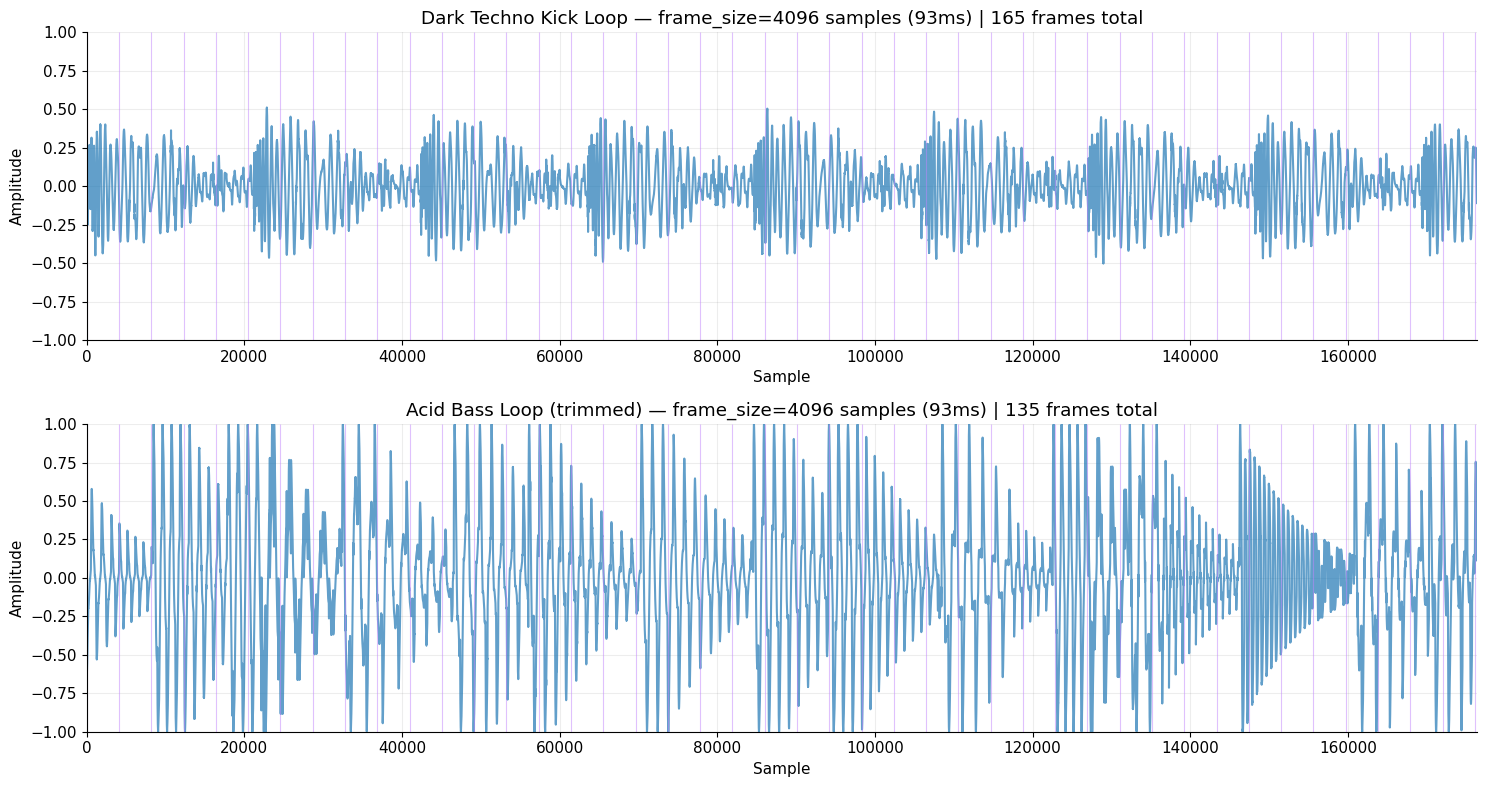

Plot saved: target_analysis_default.png


In [6]:
TARGETS = [
    {
        'path'     : '518488__cyclez__dark-techno-kick-drum-loop.wav',
        'csv'      : 'dataframe_target_kick.csv',
        'label'    : 'Dark Techno Kick Loop',
        'frame_size': 4096,
    },
    {
        'path'     : 'acid_bass_trimmed.wav',
        'csv'      : 'dataframe_target_acid.csv',
        'label'    : 'Acid Bass Loop (trimmed)',
        'frame_size': 4096,
    },
]

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(15, 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = [axes]

for idx, target in enumerate(TARGETS):
    print(f'Analyzing: {target["label"]}')
    analysis = analyze_sound(target['path'], frame_size=target['frame_size'])
    df_t = pd.DataFrame(analysis)
    df_t.to_csv(target['csv'])
    print(f'  → {len(df_t)} frames saved to {target["csv"]}')

    audio = estd.MonoLoader(filename=target['path'])()
    ax = axes[idx]
    ax.plot(audio, alpha=0.7)
    ax.vlines(df_t['start_sample'].values, -1, 1, color=C['accent'], alpha=0.5, linewidth=0.8)
    ax.set_xlim(0, min(len(audio), 44100 * 4))
    ax.set_ylim(-1, 1)
    ax.set_title(f'{target["label"]} — frame_size={target["frame_size"]} samples ({target["frame_size"]/44100*1000:.0f}ms) | {len(df_t)} frames total')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig('target_analysis_default.png', dpi=150)
plt.show()
print('Plot saved: target_analysis_default.png')

## 6. Experiment: Frame Size Comparison

We re-analyze the **kick loop** with three different frame sizes to observe how segmentation granularity changes.

| Frame size | Duration | Effect |
|---|---|---|
| 2048 | ~46ms | Very fine granularity, captures individual transients |
| 4096 | ~93ms | Default — good balance |
| 8192 | ~185ms | Coarser, more averaged timbre per frame |

The frame size used here for the **target** will determine the grain of the reconstruction in Notebook 3.

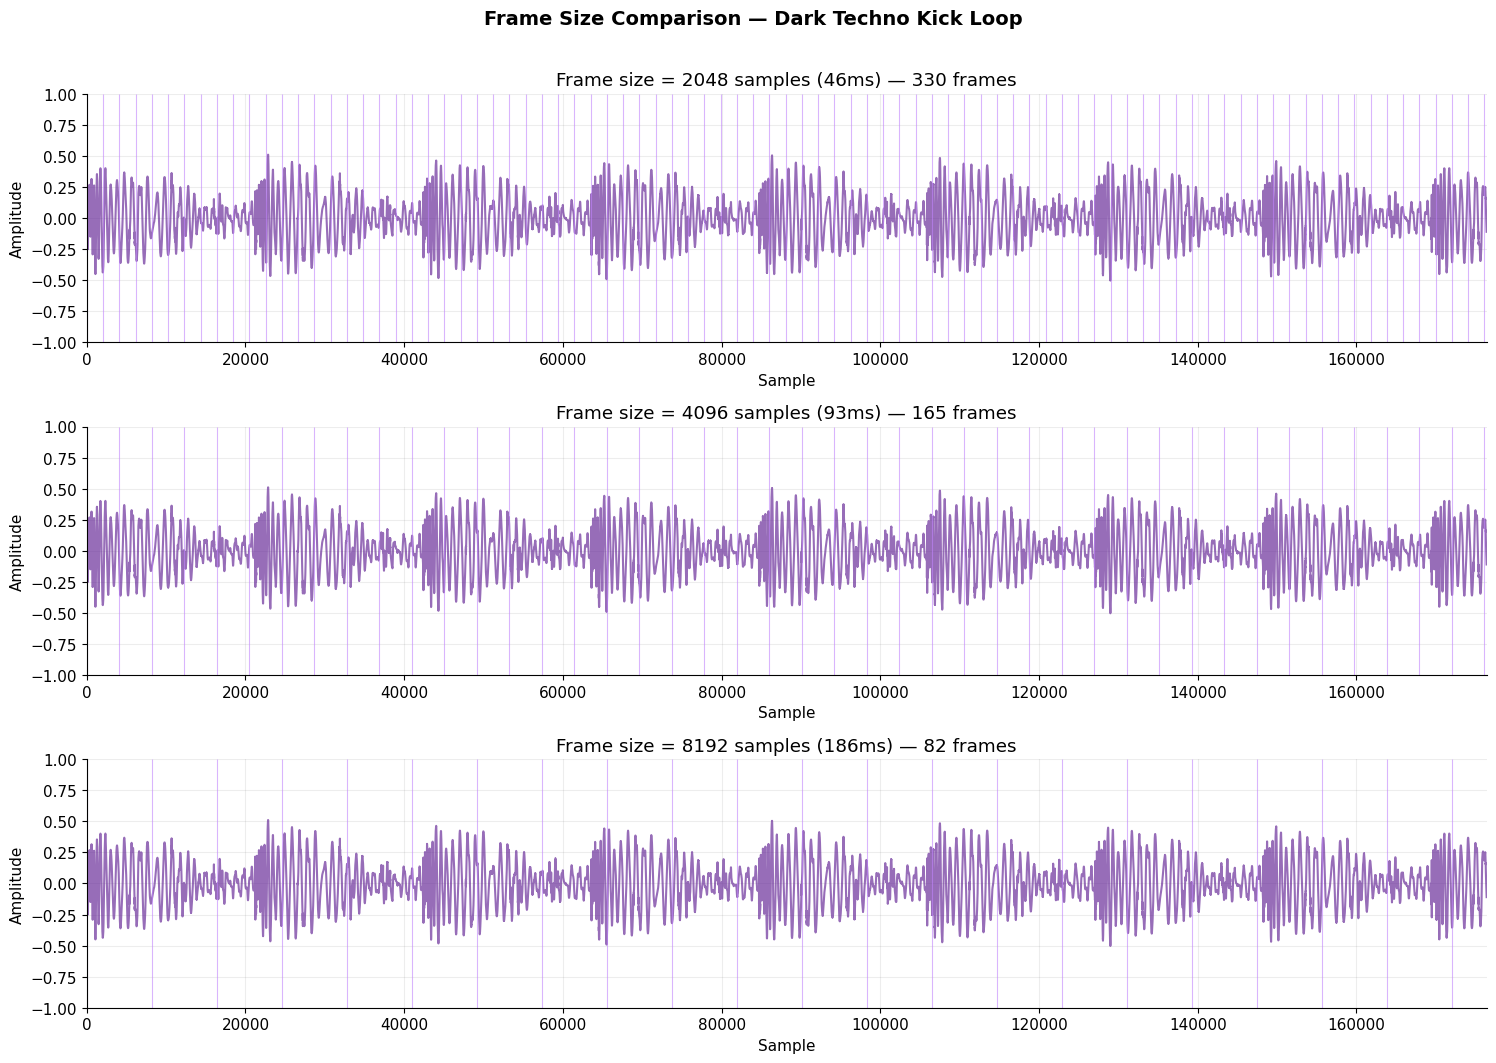

Saved: frame_size_comparison.png
Saved CSVs: dataframe_target_kick_fs2048.csv, dataframe_target_kick_fs4096.csv, dataframe_target_kick_fs8192.csv


In [7]:
KICK_PATH = '518488__cyclez__dark-techno-kick-drum-loop.wav'
FRAME_SIZES = [2048, 4096, 8192]
kick_audio = estd.MonoLoader(filename=KICK_PATH)()

fig, axes = plt.subplots(len(FRAME_SIZES), 1, figsize=(15, 3.5 * len(FRAME_SIZES)))

for idx, fs in enumerate(FRAME_SIZES):
    analysis = analyze_sound(KICK_PATH, frame_size=fs)
    df_t = pd.DataFrame(analysis)
    df_t.to_csv(f'dataframe_target_kick_fs{fs}.csv')

    ax = axes[idx]
    ax.plot(kick_audio, alpha=0.7, color=C['mid_purple'])
    ax.vlines(df_t['start_sample'].values, -1, 1, color=C['accent'], alpha=0.6, linewidth=0.8)
    ax.set_xlim(0, min(len(kick_audio), 44100 * 4))
    ax.set_ylim(-1, 1)
    ax.set_title(f'Frame size = {fs} samples ({fs/44100*1000:.0f}ms) — {len(df_t)} frames')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude')

plt.suptitle('Frame Size Comparison — Dark Techno Kick Loop', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('frame_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: frame_size_comparison.png')
print('Saved CSVs: dataframe_target_kick_fs2048.csv, dataframe_target_kick_fs4096.csv, dataframe_target_kick_fs8192.csv')

## 7. Experiment: Beat-Synchronous Segmentation

Instead of fixed-size frames, we segment the **kick loop** using beat positions detected by Essentia's `BeatTrackerDegara`.

This means each frame corresponds to one beat interval — the segmentation adapts to the rhythm of the audio.
This is particularly useful for percussive material like our kick loop.

Detecting beats and analyzing...
Beat-sync analysis: 30 frames (beats) detected


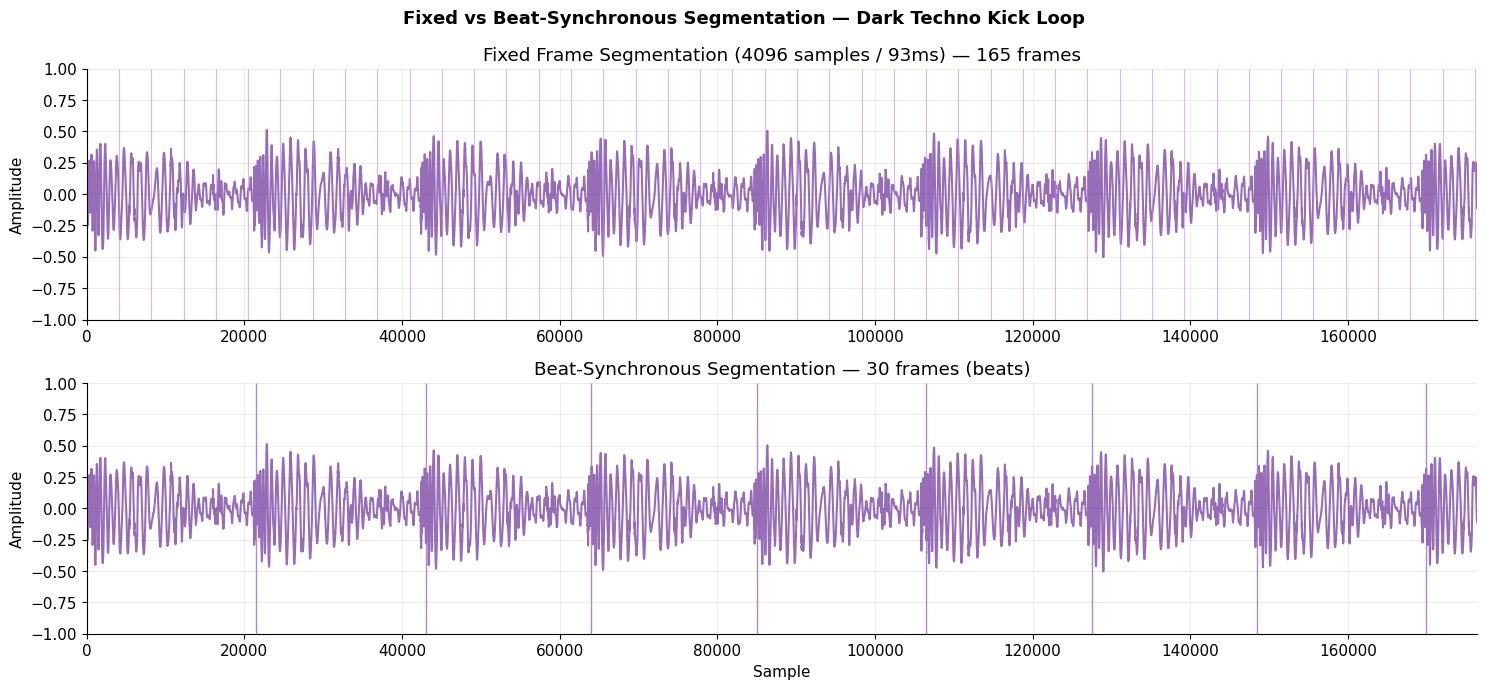

Saved: beatsync_comparison.png


In [8]:
KICK_PATH = '518488__cyclez__dark-techno-kick-drum-loop.wav'

# Analyze with beat-sync segmentation
print("Detecting beats and analyzing...")
analysis_beat = analyze_sound(KICK_PATH, sync_with_beats=True, audio_id='kick_beat')
df_beat = pd.DataFrame(analysis_beat)
df_beat.to_csv('dataframe_target_kick_beatsync.csv')
print(f'Beat-sync analysis: {len(df_beat)} frames (beats) detected')

# Compare fixed vs beat-sync visually
kick_audio = estd.MonoLoader(filename=KICK_PATH)()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7))

# Fixed frame segmentation (4096)
analysis_fixed = analyze_sound(KICK_PATH, frame_size=4096)
df_fixed = pd.DataFrame(analysis_fixed)
ax1.plot(kick_audio, alpha=0.7, color=C['mid_purple'])
ax1.vlines(df_fixed['start_sample'].values, -1, 1, color=C['accent'], alpha=0.6, linewidth=0.8)
ax1.set_xlim(0, min(len(kick_audio), 44100 * 4))
ax1.set_ylim(-1, 1)
ax1.set_title(f'Fixed Frame Segmentation (4096 samples / 93ms) — {len(df_fixed)} frames')
ax1.set_ylabel('Amplitude')

# Beat-sync segmentation
ax2.plot(kick_audio, alpha=0.7, color=C['mid_purple'])
ax2.vlines(df_beat['start_sample'].values, -1, 1, color=C['light_purple'], alpha=0.8, linewidth=1.0)
ax2.set_xlim(0, min(len(kick_audio), 44100 * 4))
ax2.set_ylim(-1, 1)
ax2.set_title(f'Beat-Synchronous Segmentation — {len(df_beat)} frames (beats)')
ax2.set_ylabel('Amplitude')
ax2.set_xlabel('Sample')

plt.suptitle('Fixed vs Beat-Synchronous Segmentation — Dark Techno Kick Loop', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('beatsync_comparison.png', dpi=150)
plt.show()
print('Saved: beatsync_comparison.png')

## 8. Feature Distribution: Source vs Targets

A quick look at how the extracted features are distributed across the source collection and both target files.
This gives an idea of how well-covered the target's feature space is by the source.

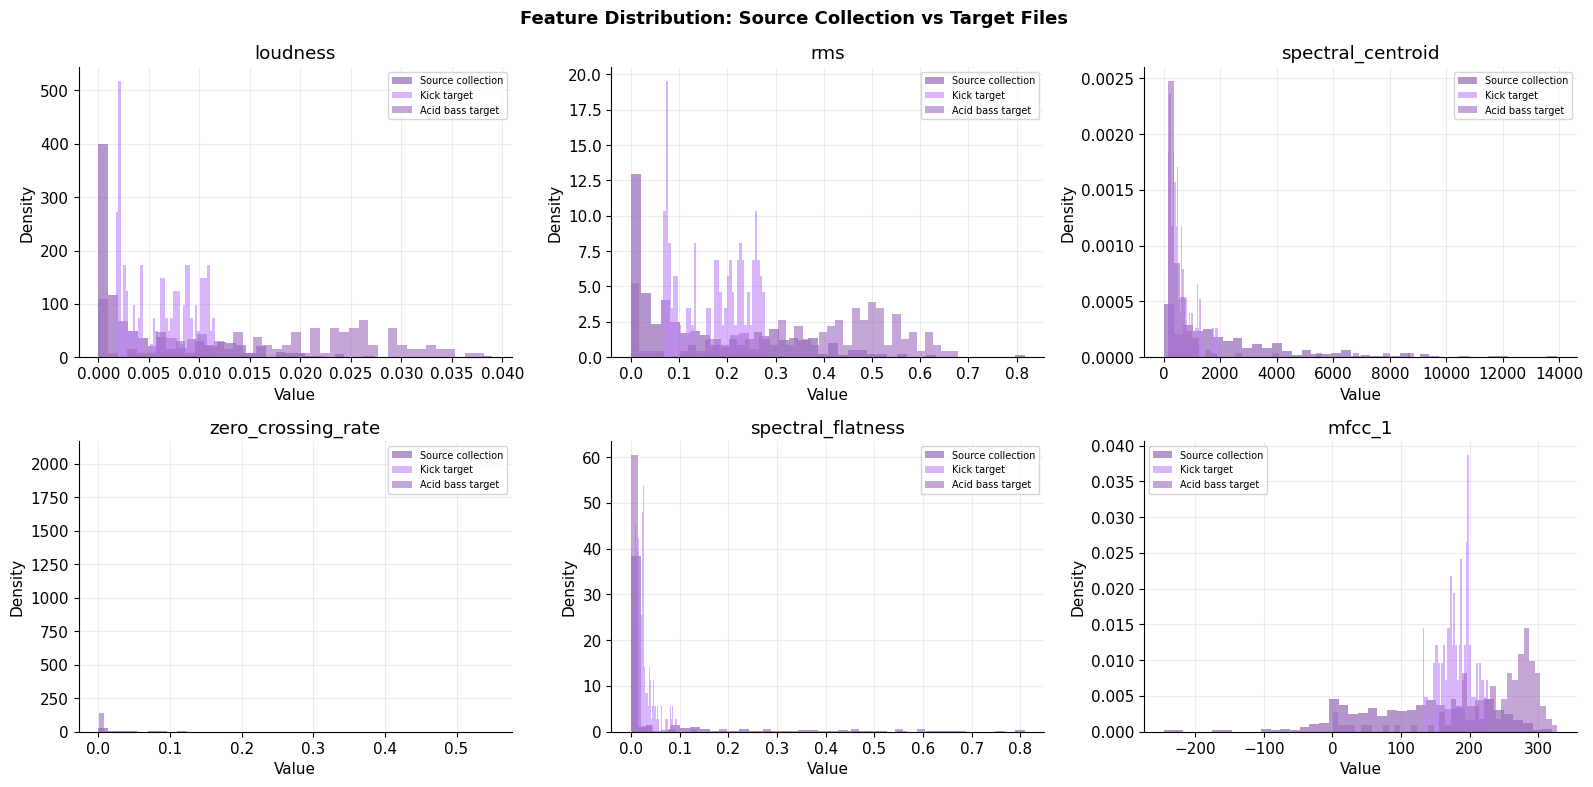

Saved: feature_distributions.png


In [9]:
# Reload default target CSVs
df_source   = pd.read_csv('dataframe_source.csv', index_col=0)
df_kick     = pd.read_csv('dataframe_target_kick.csv', index_col=0)
df_acid     = pd.read_csv('dataframe_target_acid.csv', index_col=0)

features_to_plot = ['loudness', 'rms', 'spectral_centroid', 'zero_crossing_rate', 'spectral_flatness', 'mfcc_1']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    ax.hist(df_source[feat].dropna(),  bins=40, alpha=0.5, label='Source collection', color=C['mid_purple'], density=True)
    ax.hist(df_kick[feat].dropna(),    bins=40, alpha=0.6, label='Kick target',       color=C['accent'],       density=True)
    ax.hist(df_acid[feat].dropna(),    bins=40, alpha=0.6, label='Acid bass target',  color=C['light_purple'],     density=True)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distribution: Source Collection vs Target Files', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()
print('Saved: feature_distributions.png')

## 9. Analyze Piano Source Collection

Analyze the piano collection downloaded in Notebook 1.
This produces `dataframe_source_piano.csv` which will be used in Notebook 3
for the **source collection comparison experiment**.

In [10]:
DATAFRAME_PIANO_FILENAME        = 'dataframe_piano.csv'
DATAFRAME_SOURCE_PIANO_FILENAME = 'dataframe_source_piano.csv'

if os.path.exists(DATAFRAME_PIANO_FILENAME):
    df_piano = pd.read_csv(DATAFRAME_PIANO_FILENAME, index_col=0)
    print(f"Piano collection: {len(df_piano)} sounds")

    analyses_piano = []
    for i in range(len(df_piano)):
        sound = df_piano.iloc[i]
        print(f'Analyzing [{i+1}/{len(df_piano)}] id={sound["freesound_id"]}', end='\r')
        try:
            result = analyze_sound(sound['path'], frame_size=8192, audio_id=sound['freesound_id'])
            analyses_piano += result
        except RuntimeError:
            continue

    df_source_piano = pd.DataFrame(analyses_piano)
    df_source_piano.to_csv(DATAFRAME_SOURCE_PIANO_FILENAME)
    print(f'\nSaved {len(df_source_piano)} frames → {DATAFRAME_SOURCE_PIANO_FILENAME}')
    display(df_source_piano.head())
else:
    print(f"[!] {DATAFRAME_PIANO_FILENAME} not found. Run Notebook 1 first.")

Piano collection: 43 sounds

Saved 442 frames → dataframe_source_piano.csv


,freesound_id,id,path,start_sample,end_sample,loudness,rms,mfcc_0,mfcc_1,mfcc_2,...,mfcc_9,mfcc_10,mfcc_11,mfcc_12,spectral_centroid,zero_crossing_rate,spectral_flatness,key,scale,key_strength
0,740920,740920_f0,files/740920_16083839-hq.ogg,0,8192,1.796519e-04,0.014742,-948.055420,166.446228,-24.547600,...,11.637386,-1.691132,-22.682278,-12.960800,1313.368042,0.069946,0.0,C#,major,0.552525
1,740920,740920_f1,files/740920_16083839-hq.ogg,8192,16384,1.534758e-05,0.002351,-1161.561035,69.622604,2.664574,...,42.995480,1.972679,-25.372738,-27.175283,1407.258667,0.055908,0.0,C,minor,0.584872
2,740920,740920_f2,files/740920_16083839-hq.ogg,16384,24576,5.285096e-06,0.001061,-1214.021851,36.685352,-9.214821,...,31.661724,14.272499,-15.971905,-23.222052,1592.586182,0.047485,0.0,C,minor,0.599367
3,740920,740920_f3,files/740920_16083839-hq.ogg,24576,32768,2.262819e-06,0.000563,-1238.488892,26.677021,8.084892,...,14.984722,0.136955,-5.157261,-6.702293,1764.153076,0.035767,0.0,G,minor,0.630142
4,740920,740920_f4,files/740920_16083839-hq.ogg,32768,40960,8.170741e-07,0.000263,-1252.411621,9.399429,-5.647865,...,10.563808,3.437706,-10.050716,-14.854612,2704.626709,0.041748,0.0,G,minor,0.687967


## 10. Summary of Generated Files

### CSVs (input for Notebook 3)
| File | Description |
|---|---|
| `dataframe_source.csv` | Techno source collection analysis (frame_size=8192) |
| `dataframe_source_piano.csv` | Piano source collection analysis (frame_size=8192) |
| `dataframe_target_kick.csv` | Kick loop — default frame size (4096 / 93ms) |
| `dataframe_target_acid.csv` | Acid bass loop — default frame size (4096 / 93ms) |
| `dataframe_target_kick_fs2048.csv` | Kick loop — fine grain (2048 / 46ms) |
| `dataframe_target_kick_fs4096.csv` | Kick loop — medium grain (4096 / 93ms) |
| `dataframe_target_kick_fs8192.csv` | Kick loop — coarse grain (8192 / 185ms) |
| `dataframe_target_kick_beatsync.csv` | Kick loop — beat-synchronous segmentation |

### Plots (for the report)
| File | Description |
|---|---|
| `target_analysis_default.png` | Waveforms with default frame segmentation |
| `frame_size_comparison.png` | Frame size comparison (2048 / 4096 / 8192) |
| `beatsync_comparison.png` | Fixed vs beat-synchronous segmentation |
| `feature_distributions.png` | Feature distributions: source vs targets |

In [11]:
print("All files generated successfully!")
import os
csvs = [f for f in os.listdir('.') if f.endswith('.csv')]
pngs = [f for f in os.listdir('.') if f.endswith('.png')]
print(f"CSVs: {sorted(csvs)}")
print(f"Plots: {sorted(pngs)}")

All files generated successfully!
CSVs: ['dataframe.csv', 'dataframe_piano.csv', 'dataframe_source.csv', 'dataframe_source_piano.csv', 'dataframe_target_acid.csv', 'dataframe_target_kick.csv', 'dataframe_target_kick_beatsync.csv', 'dataframe_target_kick_fs2048.csv', 'dataframe_target_kick_fs4096.csv', 'dataframe_target_kick_fs8192.csv']
Plots: ['beatsync_comparison.png', 'feature_distributions.png', 'frame_size_comparison.png', 'target_analysis_default.png']


In [ ]:
# ── Download all outputs as ZIP ───────────────────────────────────────────────
from google.colab import files
import os, zipfile

csvs_to_download = [
    'dataframe_source.csv',
    'dataframe_source_piano.csv',
    'dataframe_target_kick.csv',
    'dataframe_target_acid.csv',
    'dataframe_target_kick_fs2048.csv',
    'dataframe_target_kick_fs4096.csv',
    'dataframe_target_kick_fs8192.csv',
    'dataframe_target_kick_beatsync.csv',
]

plots_to_download = [
    'target_analysis_default.png',
    'frame_size_comparison.png',
    'beatsync_comparison.png',
    'feature_distributions.png',
]

wavs_to_download = [
    'acid_bass_trimmed.wav',
]

zip_path = 'notebook2_outputs.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for f in csvs_to_download + plots_to_download + wavs_to_download:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✓ {f}")
        else:
            print(f"  ✗ MISSING: {f}")

files.download(zip_path)
print(f"\nDownloaded: {zip_path}")

  ✓ dataframe_source.csv
  ✓ dataframe_source_piano.csv
  ✓ dataframe_target_kick.csv
  ✓ dataframe_target_acid.csv
  ✓ dataframe_target_kick_fs2048.csv
  ✓ dataframe_target_kick_fs4096.csv
  ✓ dataframe_target_kick_fs8192.csv
  ✓ dataframe_target_kick_beatsync.csv
  ✓ target_analysis_default.png
  ✓ frame_size_comparison.png
  ✓ beatsync_comparison.png
  ✓ feature_distributions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded: notebook2_outputs.zip
